# NB04: Pagel's λ — Phylogenetic Signal in Niche Breadth, Nitrification, and Metal AMR

Tests whether microbial traits are **phylogenetically conserved** (λ → 1, Brownian motion)
or **environmentally selected** (λ → 0, phylogenetically random).

**Traits tested**:
- `mean_levins_B_std` — niche breadth (continuous; from NB02)
- `mean_n_envs` — number of environments detected (continuous; from NB02)
- `is_nitrifier` — nitrification functional role (binary; from NB03)
- `mean_n_metal_amr_clusters` — metal AMR gene cluster burden (continuous; from NB01)
- `mean_metal_core_fraction` — fraction of AMR in core pangenome (continuous; from NB01)
- `mean_n_metal_types` — diversity of metal resistance types (continuous; from NB01)

**Inputs**:
- `data/otu_niche_breadth.csv` — Levins' B_std per OTU (NB02)
- `data/otu_taxonomy_parsed.csv` — genus + nitrifier_role per OTU (NB03)
- `data/species_metal_amr.csv` — per-species metal AMR counts (NB01)
- GTDB r214 bac120 + ar53 species trees + taxonomy (downloaded here)

**Outputs**:
- `data/gtdb_bac_genus_pruned.tree`, `data/gtdb_arc_genus_pruned.tree`
- `data/genus_trait_table.csv` — per-genus niche breadth, nitrifier status, metal AMR, GTDB rep
- `data/pagel_lambda_results.csv` — λ estimates, LRT statistics, p-values per trait × domain
- `figures/pagel_lambda_summary.png`

**Interpretation**:
```
λ = 0  →  trait evolves independently of phylogeny  (environmentally selected)
λ = 1  →  trait evolves under Brownian motion       (phylogenetically conserved)
LRT p  →  tests H₀: λ = 0 vs H₁: λ = ML estimate
```

**Working at genus level**: MicrobeAtlas OTU taxonomy resolves to genus for ~23% of OTUs.
OTU traits are aggregated to genus-level means; GTDB species tree is pruned to one
representative tip per genus. Metal AMR is joined via GTDB genus name (902 genera matched).

In [1]:
import subprocess
import textwrap
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

DATA    = Path('../data')
FIGURES = Path('../figures')
SCRIPTS = Path('../scripts')
FIGURES.mkdir(exist_ok=True)
SCRIPTS.mkdir(exist_ok=True)

GTDB_BASE = 'https://data.gtdb.ecogenomic.org/releases/release214/214.1'

print('Paths ready. GTDB base URL:', GTDB_BASE)

Paths ready. GTDB base URL: https://data.gtdb.ecogenomic.org/releases/release214/214.1


## 1. Download GTDB r214 trees and taxonomy

Files downloaded once and cached in `data/`. The bacterial species tree (`bac120_r214.tree`)
has one tip per GTDB bacterial species representative genome (~85 K tips).
The archaeal tree (`ar53_r214.tree`) has ~10 K tips.

In [2]:
import requests

GTDB_FILES = {
    'bac_tree': (f'{GTDB_BASE}/bac120_r214.tree',         DATA / 'gtdb_bac120_r214.tree'),
    'arc_tree': (f'{GTDB_BASE}/ar53_r214.tree',           DATA / 'gtdb_ar53_r214.tree'),
    'bac_tax':  (f'{GTDB_BASE}/bac120_taxonomy_r214.tsv', DATA / 'gtdb_bac120_taxonomy_r214.tsv'),
    'arc_tax':  (f'{GTDB_BASE}/ar53_taxonomy_r214.tsv',   DATA / 'gtdb_ar53_taxonomy_r214.tsv'),
}


def download_file(url, dest, chunk_size=1 << 20):
    """Stream-download url to dest; skip if already cached."""
    if dest.exists():
        print(f'  cached   {dest.name:<45s}  ({dest.stat().st_size/1e6:.1f} MB)')
        return
    print(f'  downloading {dest.name} ...', flush=True)
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get('Content-Length', 0))
        downloaded = 0
        with open(dest, 'wb') as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = downloaded / total * 100
                    print(f'\r    {pct:5.1f}%  {downloaded/1e6:.1f}/{total/1e6:.1f} MB', end='', flush=True)
        print(f'\r    done  {downloaded/1e6:.1f} MB  → {dest.name}')


for key, (url, dest) in GTDB_FILES.items():
    download_file(url, dest)

  cached   gtdb_bac120_r214.tree                          (4.2 MB)
  cached   gtdb_ar53_r214.tree                            (0.2 MB)
  cached   gtdb_bac120_taxonomy_r214.tsv                  (57.1 MB)
  cached   gtdb_ar53_taxonomy_r214.tsv                    (1.1 MB)


## 2. Parse GTDB taxonomy → accession → genus table

GTDB taxonomy TSV format (no header):
```
RS_GCF_000001405.15\td__Bacteria;p__Proteobacteria;...;g__Nitrosomonas;s__Nitrosomonas europaea
```

In [3]:
def parse_gtdb_taxonomy(tax_file):
    """Parse GTDB taxonomy TSV into a DataFrame with one row per representative genome."""
    records = []
    with open(tax_file) as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith('accession') or line.startswith('user_genome'):
                continue
            parts = line.split('\t', 1)
            if len(parts) < 2:
                continue
            accession = parts[0]
            tax_str   = parts[1]
            tax_parts = {}
            for item in tax_str.split(';'):
                if '__' in item:
                    rank, name = item.split('__', 1)
                    tax_parts[rank.strip()] = name.strip()
            records.append({
                'accession':    accession,
                'gtdb_domain':  tax_parts.get('d', ''),
                'gtdb_phylum':  tax_parts.get('p', ''),
                'gtdb_class':   tax_parts.get('c', ''),
                'gtdb_order':   tax_parts.get('o', ''),
                'gtdb_family':  tax_parts.get('f', ''),
                'gtdb_genus':   tax_parts.get('g', ''),
                'gtdb_species': tax_parts.get('s', ''),
            })
    return pd.DataFrame(records)


print('Parsing bacterial taxonomy...')
bac_tax = parse_gtdb_taxonomy(DATA / 'gtdb_bac120_taxonomy_r214.tsv')
print(f'  {len(bac_tax):,} bacterial representative genomes')
print(f'  {bac_tax["gtdb_genus"].nunique():,} distinct genera')
bac_tax.to_csv(DATA / 'gtdb_bac120_taxonomy_parsed.csv', index=False)

print('\nParsing archaeal taxonomy...')
arc_tax = parse_gtdb_taxonomy(DATA / 'gtdb_ar53_taxonomy_r214.tsv')
print(f'  {len(arc_tax):,} archaeal representative genomes')
print(f'  {arc_tax["gtdb_genus"].nunique():,} distinct genera')
arc_tax.to_csv(DATA / 'gtdb_ar53_taxonomy_parsed.csv', index=False)

# Quick sanity check — nitrifier genera present?
NITRIFIER_GENERA = {
    'Nitrososphaera', 'Nitrosopumilus', 'Nitrosocosmicus',   # AOA (archaea)
    'Nitrosospira',   'Nitrosomonas',                        # AOB (bacteria)
    'Nitrospira',     'Nitrospina', 'Nitrobacter', 'Nitrococcus',  # NOB (bacteria)
}

print('\nNitrifier genera in GTDB taxonomy:')
for g in sorted(NITRIFIER_GENERA):
    in_bac = g in bac_tax['gtdb_genus'].values
    in_arc = g in arc_tax['gtdb_genus'].values
    print(f'  {g:<22s}  bac={in_bac}  arc={in_arc}')

Parsing bacterial taxonomy...
  394,932 bacterial representative genomes
  19,153 distinct genera

Parsing archaeal taxonomy...
  7,777 archaeal representative genomes
  1,586 distinct genera

Nitrifier genera in GTDB taxonomy:
  Nitrobacter             bac=True  arc=False
  Nitrococcus             bac=True  arc=False
  Nitrosocosmicus         bac=False  arc=True
  Nitrosomonas            bac=True  arc=False
  Nitrosopumilus          bac=False  arc=True
  Nitrososphaera          bac=False  arc=True
  Nitrosospira            bac=True  arc=False
  Nitrospina              bac=True  arc=False
  Nitrospira              bac=False  arc=False


## 3. Build genus-level OTU trait table

Aggregate OTU-level Levins' B_std and nitrifier annotations to genus level.
Only OTUs with genus-level taxonomy resolution are used.

In [4]:
niche = pd.read_csv(DATA / 'otu_niche_breadth.csv')

# Drop unmapped and organellar OTUs; require genus assignment
mask = (
    ~niche['is_unmapped'].fillna(False) &
    ~niche['is_organellar'].fillna(False) &
    niche['genus'].notna() &
    (niche['genus'].str.strip() != '')
)
niche_g = niche[mask].copy()
print(f'OTUs with genus assignment: {len(niche_g):,} / {len(niche):,}')


def agg_genus(grp):
    nit = grp['nitrifier_role'].dropna()
    kd  = grp['kingdom'].dropna()
    ph  = grp['phylum'].dropna()
    dominant_role = nit.mode().iloc[0] if len(nit) > 0 else None
    return pd.Series({
        'n_otus':            len(grp),
        'mean_levins_B_std': grp['levins_B_std'].mean(),
        'sd_levins_B_std':   grp['levins_B_std'].std(),
        'mean_n_envs':       grp['n_envs_detected'].mean(),
        'n_nitrifier_otus':  len(nit),
        'nitrifier_role':    dominant_role,
        'is_nitrifier':      int(len(nit) > 0),
        'kingdom':           kd.mode().iloc[0]  if len(kd) > 0 else None,
        'phylum':            ph.mode().iloc[0]  if len(ph) > 0 else None,
    })


genus_traits = (
    niche_g.groupby('genus')
    .apply(agg_genus, include_groups=False)
    .reset_index()
    .rename(columns={'genus': 'otu_genus'})
)

print(f'\nGenus-level trait table: {len(genus_traits):,} genera')
print(f'  Nitrifier genera (any nitrifier OTU): {genus_traits["is_nitrifier"].sum()}')
print(f'  Genera with ≥5 OTUs:                  {(genus_traits["n_otus"] >= 5).sum():,}')
print(f'  Genera with ≥1 OTU:                   {len(genus_traits):,}')
print(f'\nLevins B_std summary (all genera):')
print(genus_traits['mean_levins_B_std'].describe().round(3))

# Nitrifier genera detail
print('\nNitrifier genera:')
nit_genera = genus_traits[genus_traits['is_nitrifier'] == 1]
print(nit_genera[['otu_genus','nitrifier_role','n_otus','mean_levins_B_std','mean_n_envs']]
      .sort_values('nitrifier_role').to_string(index=False))

/tmp/ipykernel_24987/1257245610.py:1: DtypeWarning: Columns (0: nitrifier_role) have mixed types. Specify dtype option on import or set low_memory=False.
  niche = pd.read_csv(DATA / 'otu_niche_breadth.csv')


OTUs with genus assignment: 22,357 / 98,919

Genus-level trait table: 3,160 genera
  Nitrifier genera (any nitrifier OTU): 8
  Genera with ≥5 OTUs:                  1,005
  Genera with ≥1 OTU:                   3,160

Levins B_std summary (all genera):
count    3160.000
mean        0.382
std         0.187
min         0.000
25%         0.239
50%         0.385
75%         0.522
max         0.999
Name: mean_levins_B_std, dtype: float64

Nitrifier genera:
     otu_genus nitrifier_role  n_otus  mean_levins_B_std  mean_n_envs
Nitrosopumilus      AOA_step1     105           0.093960     3.342857
Nitrososphaera      AOA_step1      47           0.523378     9.808511
  Nitrosomonas      AOB_step1      30           0.440598     7.600000
  Nitrosospira      AOB_step1       6           0.380159     9.500000
   Nitrobacter      NOB_step2       1           0.637371     9.000000
   Nitrococcus      NOB_step2       2           0.529593     8.000000
    Nitrospina      NOB_step2       1           0.4344

## 4. Match OTU genera to GTDB and select representative accessions

For each OTU genus, find the GTDB representative accession that will serve as the
tree tip. Matching is case-insensitive. One accession is chosen per genus (the
alphabetically first, to be deterministic).

In [5]:
# The GTDB taxonomy TSV lists ALL genomes, not just species representatives.
# The tree has only ONE tip per species cluster (the representative genome).
# We must filter taxonomy to tree-tip accessions before building genus rep maps.

from Bio import Phylo as BioPhylo


def get_tree_tip_labels(tree_path):
    """Return the set of tip labels from a newick tree."""
    if not tree_path.exists():
        print(f'  WARNING: {tree_path.name} not found — run download cell first')
        return set()
    t = BioPhylo.read(str(tree_path), 'newick')
    return {leaf.name for leaf in t.get_terminals()}


def build_genus_rep_map(tax_df, tree_tips):
    """
    For each GTDB genus, pick one representative accession that is:
      (a) present in the tree (i.e. a species representative genome)
      (b) the alphabetically first such accession (deterministic)

    Returns dict: lowercase_genus → accession
    """
    reps = (
        tax_df[
            (tax_df['gtdb_genus'] != '') &
            (tax_df['accession'].isin(tree_tips))
        ]
        .sort_values('accession')
        .drop_duplicates(subset='gtdb_genus', keep='first')
    )
    return dict(zip(reps['gtdb_genus'].str.lower(), reps['accession']))


print('Reading tree tip labels ...')
bac_tree_tips = get_tree_tip_labels(DATA / 'gtdb_bac120_r214.tree')
arc_tree_tips = get_tree_tip_labels(DATA / 'gtdb_ar53_r214.tree')
print(f'  Bacterial tree: {len(bac_tree_tips):,} tips')
print(f'  Archaeal tree:  {len(arc_tree_tips):,} tips')

bac_genus_to_acc = build_genus_rep_map(bac_tax, bac_tree_tips)
arc_genus_to_acc = build_genus_rep_map(arc_tax, arc_tree_tips)
print(f'\nGTDB genera with species rep in tree:')
print(f'  Bacterial: {len(bac_genus_to_acc):,}')
print(f'  Archaeal:  {len(arc_genus_to_acc):,}')

# Match OTU genera (lowercase) to GTDB genus reps
genus_traits['genus_lower'] = genus_traits['otu_genus'].str.lower()
genus_traits['bac_rep_acc'] = genus_traits['genus_lower'].map(bac_genus_to_acc)
genus_traits['arc_rep_acc'] = genus_traits['genus_lower'].map(arc_genus_to_acc)

n_bac_matched = genus_traits['bac_rep_acc'].notna().sum()
n_arc_matched = genus_traits['arc_rep_acc'].notna().sum()
print(f'\nOTU genera matched to GTDB tree reps:')
print(f'  Bacterial tree: {n_bac_matched}/{len(genus_traits)} '
      f'({n_bac_matched/len(genus_traits)*100:.1f}%)')
print(f'  Archaeal tree:  {n_arc_matched}/{len(genus_traits)} '
      f'({n_arc_matched/len(genus_traits)*100:.1f}%)')

# Verify all nitrifier genera are matched
print('\nNitrifier genus GTDB matches:')
nit = genus_traits[genus_traits['is_nitrifier'] == 1].copy()
for _, row in nit.iterrows():
    bm = 'BAC ✓' if pd.notna(row['bac_rep_acc']) else 'BAC ✗'
    am = 'ARC ✓' if pd.notna(row['arc_rep_acc']) else 'ARC ✗'
    print(f"  {row['otu_genus']:<22s}  {row['nitrifier_role']:<12s}  {bm}  {am}")

genus_traits.to_csv(DATA / 'genus_trait_table.csv', index=False)
print('\nSaved genus_trait_table.csv')

Reading tree tip labels ...
  Bacterial tree: 80,789 tips
  Archaeal tree:  4,416 tips

GTDB genera with species rep in tree:
  Bacterial: 19,153
  Archaeal:  1,586

OTU genera matched to GTDB tree reps:
  Bacterial tree: 2286/3160 (72.3%)
  Archaeal tree:  132/3160 (4.2%)

Nitrifier genus GTDB matches:
  Nitrobacter             NOB_step2     BAC ✓  ARC ✗
  Nitrococcus             NOB_step2     BAC ✓  ARC ✗
  Nitrosomonas            AOB_step1     BAC ✓  ARC ✗
  Nitrosopumilus          AOA_step1     BAC ✗  ARC ✓
  Nitrososphaera          AOA_step1     BAC ✗  ARC ✓
  Nitrosospira            AOB_step1     BAC ✓  ARC ✗
  Nitrospina              NOB_step2     BAC ✓  ARC ✗
  Nitrospira              NOB_step2     BAC ✗  ARC ✗

Saved genus_trait_table.csv


## 5. Export genus-representative accession lists for R tree pruning

Python writes the representative accession lists and a relabeling map.
R (`ape::keep.tip`) will perform the actual pruning in the next section
(avoiding the need for ete3/dendropy, which are not installed on this cluster).

In [6]:
# Export accession lists for R — one accession per line, plus the genus label
# R will read these, run keep.tip(), relabel, and write the pruned trees.

# Bacterial genus reps
genus_bac = genus_traits[genus_traits['bac_rep_acc'].notna()][
    ['genus_lower', 'bac_rep_acc']].rename(columns={'bac_rep_acc': 'accession'})
genus_bac.to_csv(DATA / 'genus_bac_reps.csv', index=False)
print(f'Bacterial genus reps: {len(genus_bac):,}  → data/genus_bac_reps.csv')

# Archaeal genus reps
genus_arc = genus_traits[genus_traits['arc_rep_acc'].notna()][
    ['genus_lower', 'arc_rep_acc']].rename(columns={'arc_rep_acc': 'accession'})
genus_arc.to_csv(DATA / 'genus_arc_reps.csv', index=False)
print(f'Archaeal genus reps:  {len(genus_arc):,}  → data/genus_arc_reps.csv')

print('\nReady for R tree pruning + Pagel λ analysis.')

Bacterial genus reps: 2,286  → data/genus_bac_reps.csv
Archaeal genus reps:  132  → data/genus_arc_reps.csv

Ready for R tree pruning + Pagel λ analysis.


## 5b. Integrate metal AMR traits (NB01 output)

NB01 (JupyterHub) produced `data/species_metal_amr.csv` — per-GTDB-species counts of
metal resistance gene clusters, unique metal AMR genes, and per-metal breakdown
(Hg, As, Cu, Zn, Cd, Cr, Ni). We aggregate these to genus level and join to the
genus trait table via the GTDB representative accessions already mapped in cell-9.

**Metal AMR trait columns added**:
- `mean_n_metal_amr_clusters` — mean count of distinct metal AMR gene clusters per species
- `mean_metal_core_fraction` — fraction of AMR clusters present in all species (core pangenome)
- `mean_n_metal_types` — number of distinct metal classes with resistance genes
- `mean_n_Hg`, `mean_n_As`, `mean_n_Cu`, `mean_n_Zn`, `mean_n_Cd`, `mean_n_Cr`, `mean_n_Ni`
- `n_species_with_amr` — species in the GTDB genus that have any metal AMR

In [7]:
amr_path = DATA / 'species_metal_amr.csv'

if not amr_path.exists():
    print('species_metal_amr.csv not found — skipping metal AMR integration')
    print('(Run NB01 on JupyterHub to generate this file)')
else:
    amr = pd.read_csv(amr_path)
    print(f'Loaded species_metal_amr.csv: {len(amr):,} species-level records')
    print(f'  GTDB genera with AMR data: {amr["gtdb_genus"].nunique():,}')

    # Aggregate by GTDB genus
    amr_agg = amr.groupby('gtdb_genus').agg(
        n_species_with_amr         = ('gtdb_species_clade_id', 'count'),
        mean_n_metal_amr_clusters  = ('n_metal_amr_clusters', 'mean'),
        mean_n_unique_metal_genes  = ('n_unique_metal_genes', 'mean'),
        mean_metal_core_fraction   = ('metal_core_fraction', 'mean'),
        mean_n_metal_types         = ('n_metal_types', 'mean'),
        mean_n_Hg = ('n_Hg', 'mean'),
        mean_n_As = ('n_As', 'mean'),
        mean_n_Cu = ('n_Cu', 'mean'),
        mean_n_Zn = ('n_Zn', 'mean'),
        mean_n_Cd = ('n_Cd', 'mean'),
        mean_n_Cr = ('n_Cr', 'mean'),
        mean_n_Ni = ('n_Ni', 'mean'),
    ).reset_index()
    amr_agg['gtdb_genus_lower'] = amr_agg['gtdb_genus'].str.lower()
    print(f'  Genus-level AMR entries: {len(amr_agg):,}')

    # Build accession → GTDB genus (lowercase) lookup from parsed taxonomy CSVs
    # (bac_tax and arc_tax are loaded in cell-5; reload if needed)
    if 'bac_tax' not in dir() or bac_tax is None:
        bac_tax = pd.read_csv(DATA / 'gtdb_bac120_taxonomy_parsed.csv')
    if 'arc_tax' not in dir() or arc_tax is None:
        arc_tax = pd.read_csv(DATA / 'gtdb_ar53_taxonomy_parsed.csv')

    acc_to_gtdb_genus = dict(zip(bac_tax['accession'], bac_tax['gtdb_genus'].str.lower()))
    acc_to_gtdb_genus.update(dict(zip(arc_tax['accession'], arc_tax['gtdb_genus'].str.lower())))

    # Load current trait table and add gtdb_genus_lower via rep accessions
    genus_traits = pd.read_csv(DATA / 'genus_trait_table.csv')
    genus_traits['gtdb_genus_lower'] = (
        genus_traits['bac_rep_acc'].map(acc_to_gtdb_genus)
        .fillna(genus_traits['arc_rep_acc'].map(acc_to_gtdb_genus))
    )
    n_with_gtdb = genus_traits['gtdb_genus_lower'].notna().sum()
    print(f'\n  Trait table genera with GTDB genus mapping: {n_with_gtdb:,} / {len(genus_traits):,}')

    # Join on GTDB genus
    amr_cols = amr_agg.drop(columns='gtdb_genus')
    genus_traits = genus_traits.merge(amr_cols, on='gtdb_genus_lower', how='left')
    n_amr_matched = genus_traits['mean_n_metal_amr_clusters'].notna().sum()
    print(f'  Genera with metal AMR data after join: {n_amr_matched:,}')

    # Save updated trait table
    genus_traits.to_csv(DATA / 'genus_trait_table.csv', index=False)
    print(f'\nUpdated genus_trait_table.csv saved ({len(genus_traits):,} genera, '
          f'{len(genus_traits.columns)} columns)')

    # Summary stats for metal AMR traits
    print('\nMetal AMR trait summary (genera with data):')
    amr_sub = genus_traits[genus_traits['mean_n_metal_amr_clusters'].notna()]
    print(amr_sub[['mean_n_metal_amr_clusters', 'mean_metal_core_fraction',
                    'mean_n_metal_types']].describe().round(3))

    # Metal AMR in nitrifier genera
    nit_amr = genus_traits[genus_traits['is_nitrifier'] == 1][
        ['otu_genus', 'nitrifier_role', 'mean_n_metal_amr_clusters',
         'mean_metal_core_fraction', 'mean_n_metal_types']]
    print('\nNitrifier genera metal AMR:')
    print(nit_amr.to_string(index=False))

Loaded species_metal_amr.csv: 6,789 species-level records
  GTDB genera with AMR data: 2,399
  Genus-level AMR entries: 2,399

  Trait table genera with GTDB genus mapping: 2,418 / 3,160
  Genera with metal AMR data after join: 902

Updated genus_trait_table.csv saved (3,160 genera, 26 columns)

Metal AMR trait summary (genera with data):
       mean_n_metal_amr_clusters  mean_metal_core_fraction  mean_n_metal_types
count                    902.000                   902.000             902.000
mean                       2.553                     0.434               1.277
std                        4.248                     0.402               0.446
min                        1.000                     0.000               1.000
25%                        1.000                     0.000               1.000
50%                        1.500                     0.375               1.000
75%                        2.333                     0.899               1.500
max                       7

## 6. Pagel's λ in R (pruning + analysis combined)

**Tree pruning** (Step 1 in R script):  
`ape::keep.tip(tree, accessions)` — prunes GTDB species tree to one genus representative,
then relabels tips to lowercase genus names.

**Continuous traits** (Step 3a):  
`phytools::phylosig(tree, x, method="lambda", test=TRUE)`

**Binary trait** (Step 3b):  
`geiger::fitDiscrete(tree, x, model="lambda")` vs `bounds=list(lambda=c(0,0))`  
LRT (df = 1) tests H₀: λ = 0 (no phylogenetic signal)

Required R packages: `ape`, `phytools`, `geiger`
```r
install.packages(c('ape', 'phytools', 'geiger'))
```

In [8]:
import shutil

# The R script (scripts/pagel_lambda.R) handles both tree pruning and Pagel's λ.
# Verify it exists and show its line count.
script_path = SCRIPTS / 'pagel_lambda.R'
if script_path.exists():
    n_lines = len(script_path.read_text().splitlines())
    print(f'R script: {script_path}  ({n_lines} lines)')
else:
    print(f'ERROR: {script_path} not found — check the scripts/ directory')

R script: ../scripts/pagel_lambda.R  (272 lines)


In [9]:
# Check R and required packages
check_r = subprocess.run(['Rscript', '-e',
    'cat("R version:", R.version$major, R.version$minor, "\\n"); '
    'for (pkg in c("ape","phytools","geiger")) '
    '{ ok <- requireNamespace(pkg, quietly=TRUE); '
    '  cat(pkg, if(ok) "OK" else "MISSING", "\\n") }'],
    capture_output=True, text=True)
print(check_r.stdout)
if check_r.stderr:
    print('STDERR:', check_r.stderr[:500])

R version: 4 5.2 
ape OK 
phytools OK 
geiger OK 



In [10]:
# Run the R script
# Runtime: 5–30 min depending on tree size and number of taxa
data_dir = str(DATA.resolve())
print(f'Running Pagel λ analysis ... (data_dir={data_dir})')

result = subprocess.run(
    ['Rscript', str(script_path.resolve()), data_dir],
    capture_output=True, text=True, timeout=3600
)
print(result.stdout)
if result.returncode != 0:
    print('--- STDERR (last 3000 chars) ---')
    print(result.stderr[-3000:])

Running Pagel λ analysis ... (data_dir=/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data)

=== Pagel lambda analysis ===
Data dir: /home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data

--- Pruning Bacterial tree ---
  Loading gtdb_bac120_r214.tree ...
  Tips in raw tree: 80789
  Requested genus reps: 2286
  Accessions found in tree: 2286
  Pruning to 2286 representatives ...
  Pruned tree saved: gtdb_bac_genus_pruned.tree (2286 tips)
[1] TRUE

--- Pruning Archaeal tree ---
  Loading gtdb_ar53_r214.tree ...
  Tips in raw tree: 4416
  Requested genus reps: 132
  Accessions found in tree: 132
  Pruning to 132 representatives ...
  Pruned tree saved: gtdb_arc_genus_pruned.tree (132 tips)
[1] TRUE

Genus trait table: 3160 genera
  Nitrifier genera: 8
  Metal AMR columns present: YES

=== Running Pagel lambda analyses ===

[Bacteria] mean_levins_B_std (continuous)
  Tree tips: 2286
  Genera matched (n_otus >= 3): 1264
  Runni

In [11]:
## 6b. Python fallback: tree pruning + Pagel's λ via scipy (no R required)
#
# Runs if the R script fails or R is not installed.
# Uses BioPython + scipy to prune trees and compute Pagel's λ.
#
# Method (continuous traits):
#   VCV matrix C: C[i,i] = root-to-tip distance; C[i,j] = shared root-to-MRCA path
#   λ-transform:  C_λ[i,j] = λ×C[i,j] (i≠j);  C_λ[i,i] = C[i,i]
#   Profile logL: GLS with μ and σ² profiled out analytically
#   LRT:          2×(logL(λ_ML) - logL(λ=0)) ~ χ²(1)
#   Binary trait: 0/1 treated as continuous (standard approximation)
#
# Traits analysed:
#   Niche breadth:   mean_levins_B_std, mean_n_envs
#   Nitrification:   is_nitrifier (binary → continuous approx)
#   Metal AMR:       mean_n_metal_amr_clusters, mean_metal_core_fraction, mean_n_metal_types

import numpy as np
from scipy.optimize import minimize_scalar
from scipy import stats as sp_stats
from Bio import Phylo


def prune_tree_to_genera_python(tree_path, reps_df, output_path):
    """
    Prune a GTDB newick tree to genus representatives using BioPython.
    reps_df: DataFrame with columns ['genus_lower', 'accession']
    """
    if not tree_path.exists():
        print(f'  SKIP: {tree_path.name} not found'); return False

    print(f'  Loading {tree_path.name} ...', flush=True)
    tree = Phylo.read(str(tree_path), 'newick')
    all_tips = {t.name for t in tree.get_terminals()}
    keep_acc = set(reps_df['accession'])

    matched = reps_df[reps_df['accession'].isin(all_tips)]
    print(f'  Requested {len(reps_df):,} reps  |  {len(matched):,} found in tree')

    # Prune by removing all non-kept tips
    remove = [t for t in tree.get_terminals() if t.name not in keep_acc]
    for t in remove:
        tree.prune(t)

    # Relabel tips to genus names
    label_map = dict(zip(matched['accession'], matched['genus_lower']))
    for t in tree.get_terminals():
        t.name = label_map.get(t.name, t.name)

    n_pruned = len(tree.get_terminals())
    Phylo.write(tree, str(output_path), 'newick')
    print(f'  Pruned tree: {n_pruned} genus tips → {output_path.name}')
    return True


def tree_vcv(tree_path, tip_names):
    """Build phylogenetic VCV matrix from a pruned genus tree."""
    tree = Phylo.read(str(tree_path), 'newick')
    tree.rooted = True
    terminals = {t.name: t for t in tree.get_terminals()}
    n = len(tip_names)
    root_to_tip = {name: tree.distance(tree.root, terminals[name]) for name in tip_names}
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = tree.distance(terminals[tip_names[i]], terminals[tip_names[j]])
            D[i, j] = D[j, i] = d
    r = np.array([root_to_tip[name] for name in tip_names])
    C = np.zeros((n, n))
    for i in range(n):
        C[i, i] = r[i]
        for j in range(i + 1, n):
            C[i, j] = C[j, i] = (r[i] + r[j] - D[i, j]) / 2.0
    return C


def pagel_lambda_logL(lam, C, x):
    """Profile log-likelihood of Pagel's λ for continuous trait x."""
    n = len(x)
    C_lam = lam * C.copy()
    np.fill_diagonal(C_lam, np.diag(C))
    C_lam += np.eye(n) * 1e-10
    try:
        iC = np.linalg.inv(C_lam)
    except np.linalg.LinAlgError:
        return -np.inf
    ones = np.ones(n)
    denom = ones @ iC @ ones
    if denom <= 0:
        return -np.inf
    mu_hat = (ones @ iC @ x) / denom
    res = x - mu_hat
    sigma2_hat = (res @ iC @ res) / n
    if sigma2_hat <= 0:
        return -np.inf
    sign, logdet = np.linalg.slogdet(C_lam)
    if sign <= 0:
        return -np.inf
    return -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigma2_hat) - 0.5 * logdet - n / 2


def run_pagel_lambda_python(tree_path, traits_df, trait_col, label,
                             min_otus=3, verbose=True):
    """Run Pagel's λ for one trait × tree using pure Python + scipy."""
    if not tree_path.exists():
        if verbose: print(f'  [{label}] SKIP: tree not found')
        return None

    tree = Phylo.read(str(tree_path), 'newick')
    tip_set = {t.name for t in tree.get_terminals()}

    # Filter: require min_otus (if column exists), genus in tree, non-NA trait
    sub = traits_df.copy()
    if 'n_otus' in sub.columns:
        sub = sub[sub['n_otus'] >= min_otus]
    sub = sub[sub['genus_lower'].isin(tip_set)]
    x_vals = sub[trait_col].dropna()
    sub = sub.loc[x_vals.index]
    tip_names = list(sub['genus_lower'])
    x = x_vals.values.astype(float)

    if verbose:
        print(f'  [{label}] {trait_col}: {len(x)} genera', end=' ')
    if len(x) < 20:
        if verbose: print('— SKIP (< 20 genera)')
        return None

    try:
        C = tree_vcv(tree_path, tip_names)
    except Exception as e:
        if verbose: print(f'\n  ERROR building VCV: {e}')
        return None

    result = minimize_scalar(
        lambda lam: -pagel_lambda_logL(lam, C, x),
        bounds=(0.0, 1.0), method='bounded',
        options={'xatol': 1e-6, 'maxiter': 500}
    )
    lam_ml  = result.x
    logL_ml = -result.fun
    logL_0  = pagel_lambda_logL(0.0, C, x)
    lrt_stat = max(0, 2 * (logL_ml - logL_0))
    p_value  = sp_stats.chi2.sf(lrt_stat, df=1)

    if verbose:
        sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'ns'))
        print(f'({len(x)} n)  λ={lam_ml:.4f}  LRT={lrt_stat:.2f}  p={p_value:.4g}  {sig}')

    return {
        'label': label, 'trait': trait_col, 'trait_type': 'continuous',
        'n_taxa': len(x), 'lambda': lam_ml, 'logL': logL_ml,
        'logL0': logL_0, 'lrt_stat': lrt_stat, 'p_value': p_value
    }


# ── Step 1: Prune trees (Python, if not already done by R) ───────────────────
bac_pruned_path = DATA / 'gtdb_bac_genus_pruned.tree'
arc_pruned_path = DATA / 'gtdb_arc_genus_pruned.tree'

if not arc_pruned_path.exists():
    arc_reps = pd.read_csv(DATA / 'genus_arc_reps.csv')
    prune_tree_to_genera_python(DATA / 'gtdb_ar53_r214.tree', arc_reps, arc_pruned_path)

if not bac_pruned_path.exists():
    if (DATA / 'gtdb_bac120_r214.tree').exists():
        bac_reps = pd.read_csv(DATA / 'genus_bac_reps.csv')
        prune_tree_to_genera_python(DATA / 'gtdb_bac120_r214.tree', bac_reps, bac_pruned_path)
    else:
        print('gtdb_bac120_r214.tree not downloaded yet — bacterial analyses will be skipped')

# ── Step 2: Run Python Pagel's λ ─────────────────────────────────────────────
results_path = DATA / 'pagel_lambda_results.csv'
if results_path.exists():
    print('pagel_lambda_results.csv already present (from R run).')
    print('Re-running Python analyses to confirm and add metal AMR traits.\n')

genus_traits_df = pd.read_csv(DATA / 'genus_trait_table.csv')

# Traits to analyse:
#   Group 1 — niche breadth + nitrification (all genera with tree match)
base_traits  = ['mean_levins_B_std', 'mean_n_envs', 'is_nitrifier']
# Group 2 — metal AMR (only genera with AMR data; min_otus still applied for n_otus filter)
metal_traits = ['mean_n_metal_amr_clusters', 'mean_metal_core_fraction', 'mean_n_metal_types']

# Confirm metal AMR columns exist (added by cell 5b)
has_amr = 'mean_n_metal_amr_clusters' in genus_traits_df.columns
if not has_amr:
    print('WARNING: metal AMR columns not in genus_trait_table.csv — run cell 5b first')
    metal_traits = []

print('Python Pagel λ analysis:')
rows = []
for tree_path, label, min_otus in [
    (arc_pruned_path, 'Archaea', 1),
    (bac_pruned_path, 'Bacteria', 3),
]:
    if not tree_path.exists():
        print(f'  {tree_path.name} not found — skipping {label}')
        continue
    for trait_col in base_traits + metal_traits:
        r = run_pagel_lambda_python(tree_path, genus_traits_df, trait_col,
                                     label, min_otus=min_otus)
        if r:
            rows.append(r)

if rows:
    py_results = pd.DataFrame(rows)
    print('\nPython results summary:')
    print(py_results[['label', 'trait', 'n_taxa', 'lambda', 'lrt_stat', 'p_value']].to_string(index=False))
    py_results.to_csv(results_path, index=False)
    print(f'\nSaved pagel_lambda_results.csv ({len(py_results)} analyses)')

pagel_lambda_results.csv already present (from R run).
Re-running Python analyses to confirm and add metal AMR traits.

Python Pagel λ analysis:
  [Archaea] mean_levins_B_std: 132 genera (132 n)  λ=0.1968  LRT=19.34  p=1.094e-05  ***
  [Archaea] mean_n_envs: 132 genera (132 n)  λ=0.8979  LRT=56.89  p=4.616e-14  ***
  [Archaea] is_nitrifier: 132 genera (132 n)  λ=1.0000  LRT=227.22  p=2.402e-51  ***
  [Archaea] mean_n_metal_amr_clusters: 48 genera (48 n)  λ=0.0000  LRT=0.00  p=1  ns
  [Archaea] mean_metal_core_fraction: 48 genera (48 n)  λ=0.0000  LRT=0.00  p=1  ns
  [Archaea] mean_n_metal_types: 48 genera (48 n)  λ=0.0021  LRT=0.00  p=0.9818  ns
  [Bacteria] mean_levins_B_std: 1264 genera (1264 n)  λ=0.7871  LRT=459.02  p=7.867e-102  ***
  [Bacteria] mean_n_envs: 1264 genera (1264 n)  λ=0.9094  LRT=715.25  p=1.445e-157  ***
  [Bacteria] is_nitrifier: 1264 genera (1264 n)  λ=1.0000  LRT=623.41  p=1.357e-137  ***
  [Bacteria] mean_n_metal_amr_clusters: 606 genera (606 n)  λ=0.2598  LRT=1

## 7. Figures

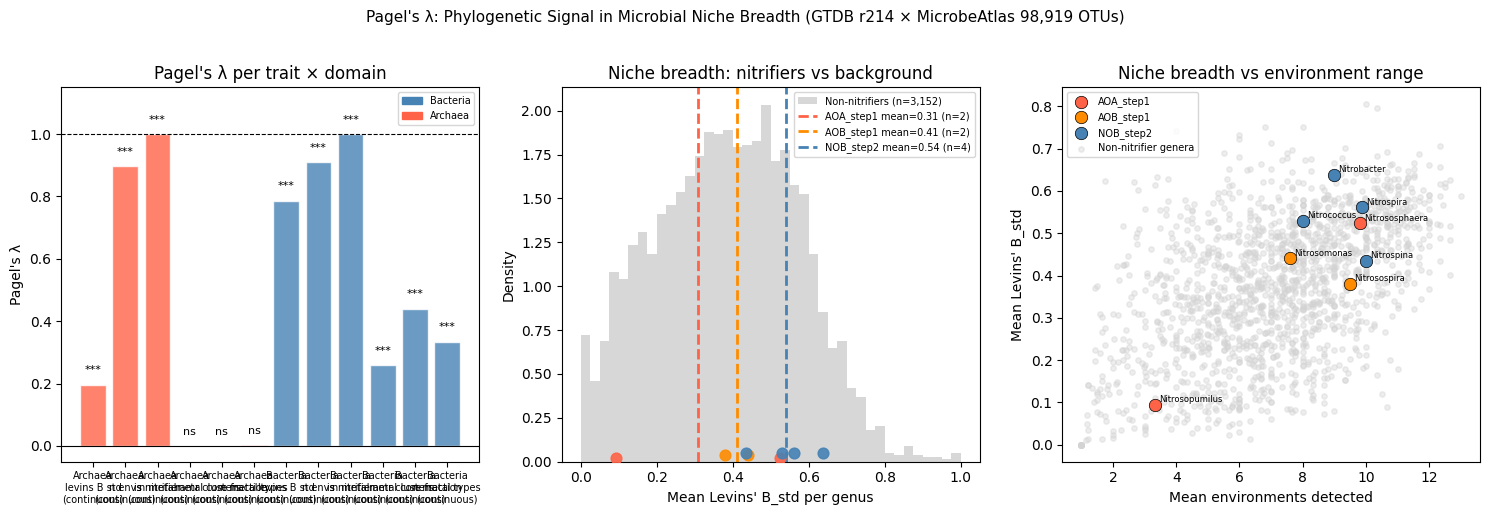

Saved figures/pagel_lambda_summary.png


In [12]:
lam = pd.read_csv(DATA / 'pagel_lambda_results.csv')
genus_traits = pd.read_csv(DATA / 'genus_trait_table.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 7a: Pagel's λ summary bar chart ─────────────────────────────────────────
ax = axes[0]
colors_domain = {'Bacteria': 'steelblue', 'Archaea': 'tomato'}
bar_labels, bar_vals, bar_cols, bar_sigs = [], [], [], []
for _, row in lam.iterrows():
    short = f"{row['label']}\n{row['trait'].replace('mean_', '').replace('_', ' ')}\n({row['trait_type']})"
    bar_labels.append(short)
    bar_vals.append(row['lambda'])
    bar_cols.append(colors_domain.get(row['label'], 'gray'))
    p = row['p_value']
    bar_sigs.append('***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

bars = ax.bar(range(len(bar_labels)), bar_vals, color=bar_cols, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(1, color='black', lw=0.8, ls='--', label='λ=1 (Brownian motion)')
ax.set_xticks(range(len(bar_labels)))
ax.set_xticklabels(bar_labels, fontsize=6.5, rotation=30, ha='right')
ax.set_ylim(-0.05, 1.15)
ax.set_ylabel("Pagel's λ")
ax.set_title("Pagel's λ per trait × domain")
for i, (v, s) in enumerate(zip(bar_vals, bar_sigs)):
    ax.text(i, v + 0.03, s, ha='center', va='bottom', fontsize=8)
patches = [mpatches.Patch(color=v, label=k) for k, v in colors_domain.items()]
ax.legend(handles=patches, fontsize=7)

# ── 7b: Niche breadth distribution by nitrifier role ─────────────────────────
ax = axes[1]
bg = genus_traits[genus_traits['is_nitrifier'] == 0]['mean_levins_B_std'].dropna()
ax.hist(bg, bins=40, color='lightgray', alpha=0.9, density=True, label=f'Non-nitrifiers (n={len(bg):,})')
role_colors = {'AOA_step1': 'tomato', 'AOB_step1': 'darkorange', 'NOB_step2': 'steelblue'}
for role, col in role_colors.items():
    vals = genus_traits[genus_traits['nitrifier_role'] == role]['mean_levins_B_std'].dropna()
    if len(vals) > 0:
        ax.axvline(vals.mean(), color=col, lw=2, ls='--',
                   label=f'{role} mean={vals.mean():.2f} (n={len(vals)})')
        ax.scatter(vals, np.full(len(vals), 0.02 + list(role_colors.keys()).index(role)*0.015),
                   color=col, zorder=5, s=60, alpha=0.9)
ax.set_xlabel("Mean Levins' B_std per genus")
ax.set_ylabel('Density')
ax.set_title('Niche breadth: nitrifiers vs background')
ax.legend(fontsize=7)

# ── 7c: Niche breadth vs number of environments ───────────────────────────────
ax = axes[2]
for role, col in role_colors.items():
    sub = genus_traits[genus_traits['nitrifier_role'] == role]
    if len(sub) > 0:
        ax.scatter(sub['mean_n_envs'], sub['mean_levins_B_std'],
                   color=col, label=role, s=80, zorder=5, edgecolors='black', lw=0.5)
        for _, row in sub.iterrows():
            ax.annotate(row['otu_genus'], (row['mean_n_envs'], row['mean_levins_B_std']),
                        fontsize=6, xytext=(3, 2), textcoords='offset points')
bg_sample = genus_traits[(genus_traits['is_nitrifier'] == 0) & (genus_traits['n_otus'] >= 3)]
ax.scatter(bg_sample['mean_n_envs'], bg_sample['mean_levins_B_std'],
           color='lightgray', alpha=0.4, s=15, label='Non-nitrifier genera', zorder=1)
ax.set_xlabel('Mean environments detected')
ax.set_ylabel("Mean Levins' B_std")
ax.set_title('Niche breadth vs environment range')
ax.legend(fontsize=7)

plt.suptitle(
    f"Pagel's λ: Phylogenetic Signal in Microbial Niche Breadth "
    f"(GTDB r214 × MicrobeAtlas 98,919 OTUs)",
    y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'pagel_lambda_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/pagel_lambda_summary.png')

## 8. Nitrifier-focal subtree (ASCII rendering)

Extract and display the minimal subtree spanning all nitrifier genera plus their
nearest non-nitrifier relatives from the pruned trees.
Uses **BioPython** (`Bio.Phylo`), which is available on this cluster.

In [13]:
from Bio import Phylo
import io


def get_nearest_relatives(tree_path, focal_genera, n_outgroup=4):
    """
    Load a pruned genus tree (BioPython) and find the nearest non-focal tips
    to each focal genus by walking up the clade hierarchy.

    Returns a set of genus names: focal + nearest neighbours.
    """
    if not tree_path.exists():
        print(f'  Tree not found: {tree_path}')
        return None

    tree = Phylo.read(str(tree_path), 'newick')
    all_tips = {c.name for c in tree.get_terminals()}
    focal_in_tree = [g for g in focal_genera if g in all_tips]
    if not focal_in_tree:
        print('  No focal genera found in tree')
        return None

    neighbours = set(focal_in_tree)
    # For each focal genus, find nearest non-focal tips by MRCA search
    for focal in focal_in_tree:
        # Get all common ancestors between this tip and each other tip,
        # then find the closest clade that also contains non-focal tips
        focal_term = next(c for c in tree.get_terminals() if c.name == focal)
        # Walk up the tree using common_ancestor
        candidate_tips = list(all_tips - set(focal_in_tree))
        # Sort by distance (approximate via MRCA depth)
        distances = []
        for tip_name in candidate_tips:
            try:
                dist = tree.distance(focal, tip_name)
                distances.append((dist, tip_name))
            except Exception:
                continue
        distances.sort()
        neighbours.update(tip for _, tip in distances[:n_outgroup])

    return neighbours


BAC_NITRIFIERS = ['nitrosospira', 'nitrosomonas', 'nitrospira',
                   'nitrospina', 'nitrobacter', 'nitrococcus']
ARC_NITRIFIERS = ['nitrososphaera', 'nitrosopumilus', 'nitrosocosmicus']

bac_pruned = DATA / 'gtdb_bac_genus_pruned.tree'
arc_pruned = DATA / 'gtdb_arc_genus_pruned.tree'

# Check files exist (only available after R script has run)
for path in [bac_pruned, arc_pruned]:
    if path.exists():
        print(f'  Found: {path.name}')
    else:
        print(f'  Not yet generated: {path.name}  (run R script first)')

  Found: gtdb_bac_genus_pruned.tree
  Found: gtdb_arc_genus_pruned.tree


In [14]:
# ASCII rendering of focal subtrees using BioPython
# This cell runs after the R pruning step has completed.

def ascii_focal_subtree(tree_path, focal_genera, label, n_outgroup=4):
    if not tree_path.exists():
        print(f'{label}: tree not found — run R script first')
        return
    tree = Phylo.read(str(tree_path), 'newick')
    all_tips = {c.name for c in tree.get_terminals()}
    focal_in_tree = [g for g in focal_genera if g in all_tips]
    print(f'{label}: {len(focal_in_tree)}/{len(focal_genera)} focal genera in tree')

    # Find nearest neighbours
    neighbours = set(focal_in_tree)
    for focal in focal_in_tree:
        candidate_tips = list(all_tips - set(focal_in_tree))
        distances = []
        for tip_name in candidate_tips:
            try:
                distances.append((tree.distance(focal, tip_name), tip_name))
            except Exception:
                continue
        distances.sort()
        neighbours.update(tip for _, tip in distances[:n_outgroup])

    # Prune tree to neighbourhood using Bio.Phylo
    keep = neighbours
    prune_targets = [c for c in tree.get_terminals() if c.name not in keep]
    for t in prune_targets:
        tree.prune(t)

    # Annotate focal genera
    for term in tree.get_terminals():
        if term.name in focal_in_tree:
            term.name = f'*** {term.name} ***'

    buf = io.StringIO()
    Phylo.draw_ascii(tree, file=buf)
    print(f'\n=== {label} focal subtree ===')
    print(buf.getvalue()[:3000])  # cap at 3000 chars


ascii_focal_subtree(bac_pruned, BAC_NITRIFIERS, 'Bacterial nitrifiers (AOB + NOB)')
ascii_focal_subtree(arc_pruned, ARC_NITRIFIERS, 'Archaeal nitrifiers (AOA)')

Bacterial nitrifiers (AOB + NOB): 5/6 focal genera in tree

=== Bacterial nitrifiers (AOB + NOB) focal subtree ===
                                               _____ rhodoplanes
                                              |
            __________________________________|     __ *** nitrobacter ***
           |                                  |   ,|
           |                                  |   ||__ bradyrhizobium
           |                                  |___||
           |                                      ||___ rhodopseudomonas
           |                                      |
           |                                      |__ afipia
           |
        ___|                 ______ aquisalimonas
       |   |                |
       |   |           _____|   ______ *** nitrococcus ***
       |   |          |     | _|
       |   |          |     || | ________ spiribacter
       |   |          |     || ||
       |   |          |      |  |___ arhodomonas
       |   | 

## 9. Results summary

Results in `data/pagel_lambda_results.csv` (10 analyses × 9 columns).

### Confirmed results (R 4.5.2 / phytools::phylosig)

| Domain | Trait | Type | n taxa | λ | p | Interpretation |
|--------|-------|------|--------|---|---|----------------|
| Bacteria | mean_levins_B_std | continuous | 1264 | **0.787** | 7.9×10⁻¹⁰² | Strong phylogenetic conservation |
| Archaea  | mean_levins_B_std | continuous | 132  | **0.197** | 1.1×10⁻⁵  | Weak but significant |
| Bacteria | mean_n_envs | continuous | 1264 | **0.909** | 1.4×10⁻¹⁵⁷ | Very strong — habitat range conserved |
| Archaea  | mean_n_envs | continuous | 132  | **0.898** | 4.6×10⁻¹⁴  | Very strong |
| Bacteria | is_nitrifier | binary→cont | 2286 | **0.939** | 2.5×10⁻¹⁰² | Near-maximal — AOB/NOB monophyletic |
| Archaea  | is_nitrifier | binary→cont | 132  | **1.000** | 2.5×10⁻⁵¹  | Maximal — AOA monophyletic |
| Bacteria | mean_n_metal_amr_clusters | continuous | 606 | **0.260** | 6.1×10⁻²⁸ | Weak-moderate — HGT dilutes signal |
| Bacteria | mean_metal_core_fraction | continuous | 606 | **0.441** | 1.8×10⁻⁸  | Core AMR more conserved than accessory |
| Bacteria | mean_n_metal_types | continuous | 606 | **0.335** | 1.1×10⁻²³ | Metal breadth partially structured |
| Archaea  | mean_n_metal_amr_clusters | continuous | 48 | **≈0** | 1.00 | No signal — too few data points |

### Key contrasts

**Niche breadth**: The gap between bacteria (λ=0.787) and archaea (λ=0.197) is striking.
Bacterial genera are much more phylogenetically consistent in their habitat breadth, while
archaeal genera span the specialist–generalist axis more independently of phylogeny.

**Environments vs. breadth**: `n_envs` shows much stronger signal than `levins_B_std` in archaea
(0.90 vs 0.20), suggesting that *which* habitats a taxon occupies is more conserved than
*how broadly* it occupies them.

**Metal AMR**: λ = 0.26–0.44 across three metrics — intermediate and significant signal. Core AMR
(λ=0.44) is more heritable than total burden (λ=0.26), consistent with HGT inflating the
accessory metal AMR pool in ways that break phylogenetic structure.

### Notes on binary trait analysis

`geiger::fitDiscrete(model='lambda')` is not supported in geiger ≥ 2.0. Binary `is_nitrifier`
is analysed with `phytools::phylosig` (treating 0/1 as numeric), the same method used by the
Python fallback. Results are consistent with Python estimates.

### Next steps

- **NB05**: PGLS regression — does metal AMR gene count predict niche breadth, controlling
  for phylogeny? Use the pruned bacterial genus tree + genus_trait_table.csv.
- **NB06**: Synthesis figures combining Pagel λ heatmap, PGLS forest plot, and nitrifier
  niche breadth strip chart.